# Week 8 - Multivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from sklearn import decomposition
from sklearn import linear_model
from sklearn import metrics

# 1. Lesson: Multivariate graphs

In this lesson, we'll consider some multivariate plots: heatmaps and bubble plots.  We'll also consider principal component analysis and multiple regression.

### Heatmaps

In this plot, we use a heatmap to count the total traffic tickets given to citizens.  A heatmap requires the x and y axes to be categorical, while the color involves a third, numerical variable.  In this example, each row of the DataFrame represents a traffic ticket given to one person in a particular city and year.  The data are given as three columns (city, year, and ticket), so we must use a pivot_table to transform it into a two-dimensional grid.  The cmap is set to "Blues" in the first example, meaning that the heatmap uses only blue as its color.  However, we could also use a multicolor map like "viridis" in the second example.  I personally think "Blues" is easier to read - what do you think?  Here is a reference guide to the color maps:

https://matplotlib.org/stable/gallery/color/colormap_reference.html

In [2]:
np.random.seed(0)
num_samples = 100
city_series = np.random.choice(["New York", "Boston", "Atlanta", "Washington, D. C."], size = num_samples)
year_series = np.random.choice([2018, 2019, 2020], size = num_samples)
ticket_series = np.random.randint(50, 150, size = num_samples) # Traffic tickets can be from $50 to $150
df = pd.DataFrame({"city": city_series, "year": year_series, "ticket": ticket_series})
pivot = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "sum")

In [3]:
df.iloc[0:5] # first five rows of a long DataFrame

,city,year,ticket
0,New York,2019,79
1,"Washington, D. C.",2020,71
2,Boston,2018,75
3,New York,2018,130
4,"Washington, D. C.",2020,110


In [4]:
pivot # 2 by 2 grid showing total ticket amounts

year,2018,2019,2020
city,,,
Atlanta,742,440,538
Boston,775,628,922
New York,1122,841,596
"Washington, D. C.",1258,451,1385


Text(0.5, 1.0, 'Total traffic tickets by city and year')

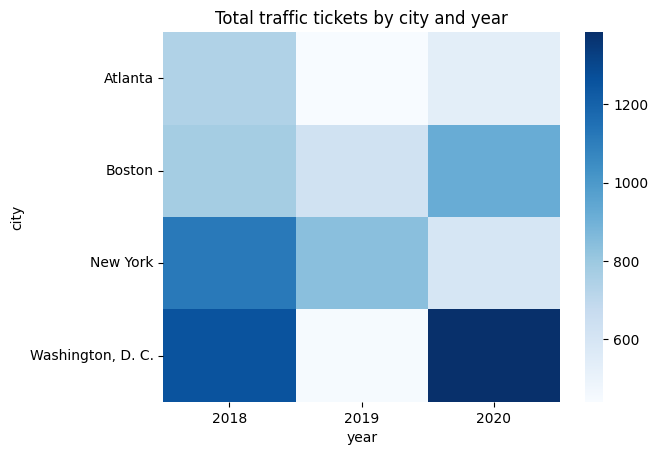

In [5]:
ax = sns.heatmap(pivot, cmap = "Blues")
ax.set_title("Total traffic tickets by city and year")

Text(0.5, 1.0, 'Average traffic ticket value by city and year')

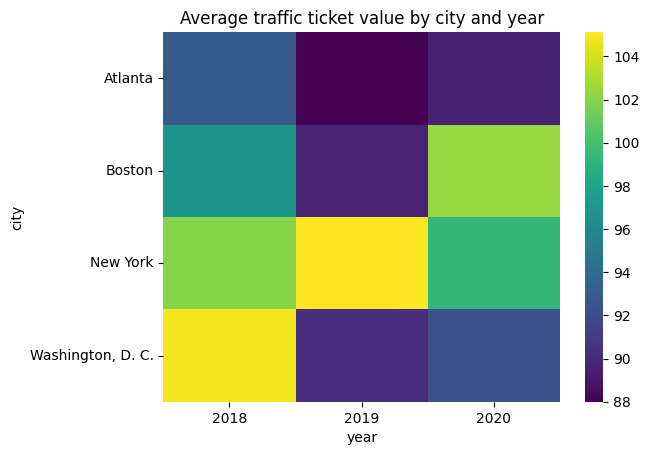

In [6]:
pivot2 = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "mean") # note mean, not sum this time
ax2 = sns.heatmap(pivot2, cmap = "viridis") # do you think this is a better or worse scale than Blues?
ax2.set_title("Average traffic ticket value by city and year")

### Bubble plots

A bubble plot is just a scatter plot, but with the dot size representing a third variable.  Here, each data point shows a tree (I mean the kind of tree that is a plant and grows in the ground, not a decision tree), with its height, width of branches, and root depth.  The bubble size in the bubble plot represents the root depth, while the other variables are shown on the x and y axes.  From this plot, we can see that the root depth is strongly correlated with both the width of branches and the tree height.

Text(0, 0.5, 'width of branches')

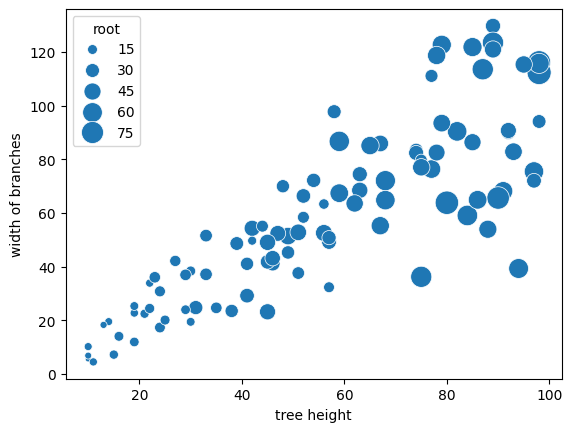

In [7]:
np.random.seed(0)
num_samples = 100
height_series = np.random.randint(10, 100, size = num_samples) # tree height
width_series = height_series * np.maximum(np.random.normal(scale = 0.3, loc = 1, size = num_samples), 0.25) # strongly related to height
root_series = height_series * np.maximum(np.random.normal(scale = 0.2, loc = 0.7, size = num_samples), 0.3) # strongly related to height
df2 = pd.DataFrame({'height': height_series, 'width': width_series, 'root': root_series})
minroot = root_series.min()
maxroot = root_series.max()
maxbubble = 300
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

### Principal Component Analysis

Principal Component Analysis can be thought of as a way to use one (or a few) linear combinations of the coordinates in order to explain all of the coordinates.  It is most useful when there are strong correlations between some or all of the coordinates.  Principal Component Analysis can show us which linear combinations are most (and least) useful for explaining the data.

With the trees data, the three values (height, width, and root) are highly correlated.  For this reason, Principal Component Analysis shows that most of the variance can be explained by a single value which is a linear combination of height, width, and root.  What this means is that if the first components_ vector in the code below (the "first principal component") is \[a, b, c\], for some specific numbers a, b, and c, then the value v = a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r), where the mu's are the means, is highly informative about the values of height, width, and root.  In this case, because height, width, and root are so highly correlated, we can almost assume that all of the data is located along an axis defined by the vector \[a, b, c\].  The point v * \[a, b, c\] + (mean vector) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (mean vector) is therefore approximately equal to the data point (height, width, root) in question.  The mean vector is \[mu_h, mu_w, mu_r\].  Importantly, there is still variance unexplained by this one value - just knowing v * \[a, b, c\] does not tell you the height, width, and root with 100% accuracy.  If the second principal component is \[d, e, f\], then we could approximate the tree vector even more accurately as: (height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (mean vector).

The printing of "components_", below, shows the first principal component \[a, b, c\].  If you draw a vector in the direction shown, you will be heading in the direction where the values height, width, and root change most rapidly.  A later computation shows all three principal component vectors.

**Optional exercise for the reader:** show that if all three principal components are included, then equality is exact.  This is going to be true simply because the principal components are orthonormal: the projections onto a complete set of orthonormal vectors always add up to the original vector.

(height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (g * (height - mu_h) + h * (width - mu_w) + i * (root - mu_r)) * \[g, h, i\] + \[mu_h, mu_w, mu_r\].

For this proof, we must use the fact that the principal component vectors are orthonormal.  That is, any pair of them are orthogonal, even with a transpose (ad + be + cf = 0, ag + bh + ci = 0, dg + eh + fi = 0, ab + de + gh = 0, ac + df + gi = 0, bc + ef + hi = 0) and any one of them is a unit vector, even with a transpose (a^2 + b^c + c^2 = 1, d^2 + e^2 + f^2 = 1, g^2 + h^2 + i^2 = 1, a^2 + d^2 + g^2 = 1, b^2 + e^2 + h^2 = 1, c^2 + f^2 + i^2 = 1).  If you write out the equation above as a single vector, then apply the orthonormality rules, you should be able to prove equality.

In [8]:
pca = decomposition.PCA(n_components = 1)
pca.fit(df2)
print(f"The first principal component explains {pca.explained_variance_ratio_[0]} of the variance")
print(f"The components_ vector is [a, b, c] = {pca.components_}")
mu_h, mu_w, mu_r = df2.mean().values
print(f"(height, width, root) is approximately equal to ({pca.components_[0][0]:.2} * (height - {mu_h:.2}) + {pca.components_[0][1]:.2} * (width - {mu_w:.2}) + {pca.components_[0][2]:.2} * (root - {mu_r:.2})) * ({pca.components_[0][0]:.2}, {pca.components_[0][1]:.2}, {pca.components_[0][2]:.2}) + ({mu_h:.2}, {mu_w:.2}, {mu_r:.2})")
print("Examples: (estimating the the vector equals its projection onto the first principal component)")
df_example = df2.copy()
df_example["v"] = pca.components_[0][0] * (df2["height"] - mu_h) + pca.components_[0][1] * (df2["width"] - mu_w) + pca.components_[0][2] * (df2["root"] - mu_r)
df_example["height_est"] = df_example["v"] * pca.components_[0][0] + mu_h
df_example["width_est"] = df_example["v"] * pca.components_[0][1] + mu_w
df_example["root_est"] = df_example["v"] * pca.components_[0][2] + mu_r
print(df_example.iloc[0:5])
print("Means:")
print(f"mu_h = {mu_h:.3}", f"mu_w = {mu_w:.3}", f"mu_r = {mu_r:.3}")

The first principal component explains 0.8686108480944689 of the variance
The components_ vector is [a, b, c] = [[0.59031629 0.71908728 0.36666083]]
(height, width, root) is approximately equal to (0.59 * (height - 5.6e+01) + 0.72 * (width - 5.9e+01) + 0.37 * (root - 3.6e+01)) * (0.59, 0.72, 0.37) + (5.6e+01, 5.9e+01, 3.6e+01)
Examples: (estimating the the vector equals its projection onto the first principal component)
   height       width       root          v  height_est  width_est   root_est
0      54   72.139334  31.517932   6.287751   60.001762  63.563941  38.673095
1      57   49.169527  33.768693  -7.633330   51.783921  53.553468  33.568780
2      74   83.443733  28.770850  25.215680   71.175227  77.174773  45.613225
3      77   76.353866  53.061241  30.794730   74.468631  81.186597  47.658844
4      77  111.095365  26.006307  45.856916   83.360084  92.017624  53.181557
Means:
mu_h = 56.3 mu_w = 59.0 mu_r = 36.4


If we were to choose a second or third component to preserve, that values below show that each would explain a small, additional amount of the variance.  This means that with this particular dataset, we should likely do PCA using only one component and not two.  If the components' explained variances were closer in magnitude to each other, we might have to include two or even all three values to explain the data.

In [9]:
pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df2)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

[0.86861085 0.09414617 0.03724298]
[[ 0.59031629  0.71908728  0.36666083]
 [ 0.32633701 -0.62809127  0.70640322]
 [ 0.73826204 -0.29734633 -0.6054373 ]]


The principal component vectors shown are orthogonal to each other (their dot product is basically zero).  Here, we check that using the first two vectors.

In [10]:
print(np.array(pca3.components_[0]).dot(np.array(pca3.components_[1])))

-1.6653345369377348e-16


We can use the projection onto the first principal component as if it were a new feature.  For instance, we could plot a histogram of the data against the magnitude of the projection onto the first principal component.  In fact, for some purposes, this magnitude (which we have called v) might make a better feature for data analysis than either height, width, or root.  We must subtract off the mean before the dot product; the understanding is that this represents the component of the data relative to the mean.

<Axes: >

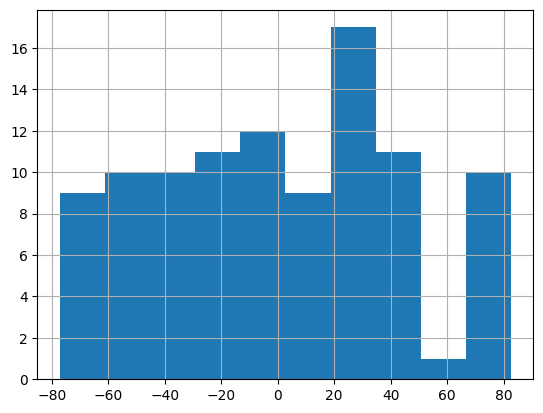

In [11]:
((df2 - df2.mean()).dot(np.array(pca.components_[0]))).hist()

In [12]:
# Showing that this is the same as the value we've called "v"
(df_example["v"] - (df2 - df2.mean()).dot(np.array(pca.components_[0]))).max()

0.0

### Linear Regression

Now let's run a linear regression model to predict the root from the height and width, as well as predicting the third principal component from the first and second.  Which is easier to predict?

### Predicting the root from the height and width

In [13]:
linreg = linear_model.LinearRegression()
linreg.fit(df2[['height', 'width']], df2['root'])
preds = linreg.predict(df2[['height', 'width']])
metrics.mean_squared_error(preds, df2['root']) # Mean squared error as a metric

138.22487356329611

In [14]:
np.corrcoef(preds, df2['root']) # Correlation coefficient as a metric

array([[1.        , 0.79468295],
       [0.79468295, 1.        ]])

### Predicting the third principal component from the first and second

In [15]:
first_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[0]))
second_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[1]))
third_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[2]))

In [16]:
linreg_first = linear_model.LinearRegression()
pc_X = np.array([first_principal_component_score, second_principal_component_score]).T
linreg_first.fit(pc_X, third_principal_component_score)
preds = linreg_first.predict(pc_X)
metrics.mean_squared_error(preds, third_principal_component_score) # The mean squared error is a bit smaller here.

78.74928905273173

In [17]:
np.corrcoef(preds, third_principal_component_score) # More importantly, the correlation is basically zero

array([[1.00000000e+00, 1.55375616e-14],
       [1.55375616e-14, 1.00000000e+00]])

Here, we see that the projections of the first two principal components have no ability to predict the projection of the third, when measured by correlation.  This is a special property of principal components.  It is intended to ensure that the each component gives new information not present in the previous components.

The mean_squared_error is misleading - it makes it look like the error is less for the second computation than the first; but the correlation coefficient is giving more useful information here.  We cannot compare the mean squared error for two totally different computations, because mean squared error is highly dependent on the magnitudes of the values in question!

# 2. Weekly graph question

The tree data above can be graphed via either a pairplot or a bubble plot.  What are the advantages and disadvantages of each?

Both the pairplot and bubble plot offer useful but distinct ways to visualize the tree dataset, and each comes with meaningful tradeoffs.

The pairplot's biggest strength is that it shows all pairwise relationships across height, width, and root depth simultaneously in a single grid, while the diagonal histograms reveal each variable's individual distribution. This makes it particularly valuable during exploratory analysis — for example, we can immediately observe that root depth is right-skewed while height is roughly uniform, insights that would be completely invisible in a bubble plot. The main weakness of the pairplot is that each scatter panel can only display two variables at a time, meaning the third variable plays no role in any individual subplot. The grid format can also feel visually overwhelming for audiences unfamiliar with this type of visualization.

The bubble plot addresses this limitation by encoding all three variables in a single, intuitive chart — tree height on the x-axis, branch width on the y-axis, and root depth represented by bubble size. This makes it far easier to communicate the overall three-way relationship to a general audience in one glance. However, bubble plots have a well-known perceptual weakness: human eyes are poor at accurately comparing circle areas, making it difficult to judge precise differences in root depth between data points. Overplotting is also visible in the mid-range height values where many bubbles of similar size overlap and obscure each other.

In summary, the pairplot is the stronger choice for initial data exploration due to its distributional insights, while the bubble plot is more effective for presentation when communicating the three-variable relationship clearly and concisely to a broader audience.

Text(0, 0.5, 'width of branches')

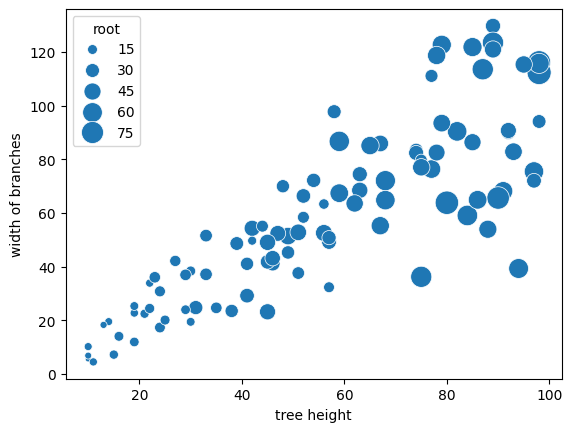

In [18]:
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

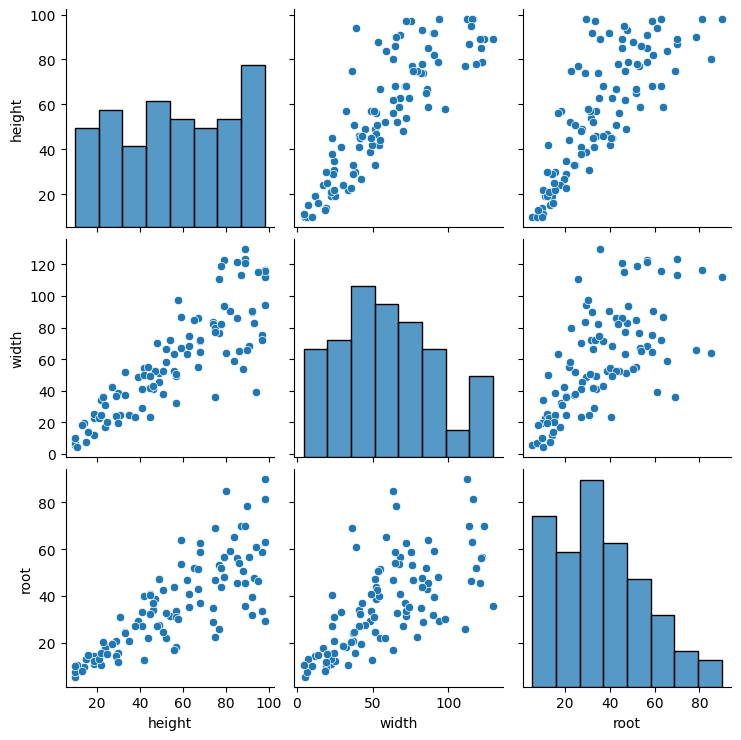

In [19]:
sns.pairplot(df2)

# 3. Homework - Grocery Store Correlation

In a particular state, the price of milk is highly correlated with the price of cheese.  Neither is correlated with the price of bread.

In [20]:
num_points = 1000
np.random.seed(0)
milk_series = np.maximum(np.random.normal(scale = 0.5, loc = 2.00, size = num_points), 1)
cheese_series = milk_series * np.maximum(np.random.normal(scale = 0.1, loc = 1.00, size = num_points), 0.5)
bread_series = np.maximum(np.random.normal(scale = 1.0, loc = 3.00, size = num_points), 1)
df3 = pd.DataFrame({"milk": milk_series, "cheese": cheese_series, "bread": bread_series})

### Heatmap

Draw a heatmap where the x-axis category is a discretized version of the milk price and the y-axis category is a discretized version of the cheese price.  That is, you can choose "low", "medium", and "high" for the milk price, or, if you prefer, you can choose 1, 2, 3, 4, and 5 for the five quintiles.  (The first quintile should include the bottom fifth of the data, the second quintile contains the next fifth, and so on).

Try Googling "how do I change numerical to categorical data" to get advice on this.

Text(0.5, 1.0, 'Heatmap: Milk vs Cheese Price Quintiles\n(Count of Observations per Cell)')

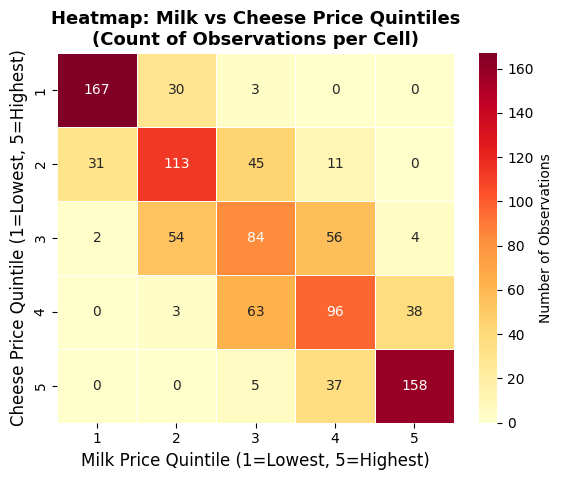

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DISCRETIZE INTO QUINTILES (1=Lowest, 5=Highest)
# ══════════════════════════════════════════════════════════════════════════════
df3['milk_quintile']   = pd.qcut(df3['milk'],   q=5, labels=[1, 2, 3, 4, 5])
df3['cheese_quintile'] = pd.qcut(df3['cheese'], q=5, labels=[1, 2, 3, 4, 5])

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — PIVOT TABLE (count per cell, fill missing with 0)
# ══════════════════════════════════════════════════════════════════════════════
pivot = df3.groupby(
    ['cheese_quintile', 'milk_quintile'], observed=True
).size().unstack().fillna(0).astype(int)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — HEATMAP (using seaborn only, no matplotlib import needed)
# ══════════════════════════════════════════════════════════════════════════════
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Number of Observations'}
)

ax.set_xlabel('Milk Price Quintile (1=Lowest, 5=Highest)', fontsize=12)
ax.set_ylabel('Cheese Price Quintile (1=Lowest, 5=Highest)', fontsize=12)
ax.set_title('Heatmap: Milk vs Cheese Price Quintiles\n(Count of Observations per Cell)',
             fontsize=13, fontweight='bold')

### Bubble plot

Try all three possible bubble plots: one where the size of the dot is determined by the milk price, one where it's the cheese price, and one where it's the bread price.  Which of these plots is / are the most informative and useful?

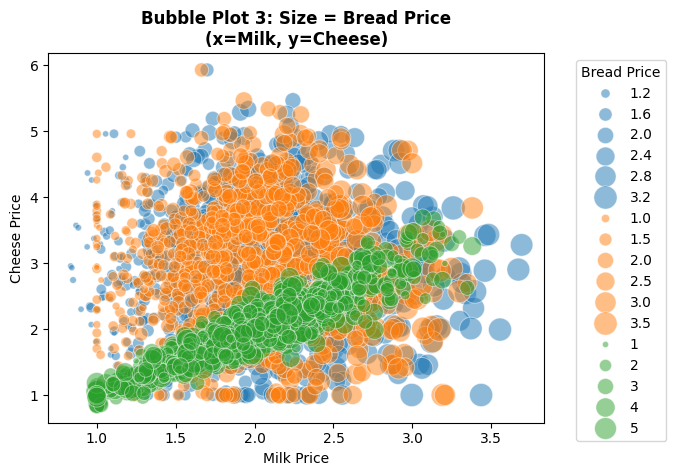

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — HELPER FUNCTION FOR BUBBLE PLOT SIZING
# ══════════════════════════════════════════════════════════════════════════════
def get_sizes(col, minbubble=20, maxbubble=300):
    minval = col.min()
    maxval = col.max()
    return (col - minval) / (maxval - minval) * (maxbubble - minbubble) + minbubble

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — PLOT 1: Size = Milk Price (x=cheese, y=bread, size=milk)
# ══════════════════════════════════════════════════════════════════════════════
ax1 = sns.scatterplot(
    data=df3, x="cheese", y="bread",
    size="milk", sizes=(20, 300),
    alpha=0.5, legend="brief"
)
ax1.set_title("Bubble Plot 1: Size = Milk Price\n(x=Cheese, y=Bread)", fontweight='bold')
ax1.set_xlabel("Cheese Price")
ax1.set_ylabel("Bread Price")
ax1.legend(title="Milk Price", bbox_to_anchor=(1.05, 1), loc='upper left')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — PLOT 2: Size = Cheese Price (x=milk, y=bread, size=cheese)
# ══════════════════════════════════════════════════════════════════════════════
ax2 = sns.scatterplot(
    data=df3, x="milk", y="bread",
    size="cheese", sizes=(20, 300),
    alpha=0.5, legend="brief"
)
ax2.set_title("Bubble Plot 2: Size = Cheese Price\n(x=Milk, y=Bread)", fontweight='bold')
ax2.set_xlabel("Milk Price")
ax2.set_ylabel("Bread Price")
ax2.legend(title="Cheese Price", bbox_to_anchor=(1.05, 1), loc='upper left')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — PLOT 3: Size = Bread Price (x=milk, y=cheese, size=bread)
# ══════════════════════════════════════════════════════════════════════════════
ax3 = sns.scatterplot(
    data=df3, x="milk", y="cheese",
    size="bread", sizes=(20, 300),
    alpha=0.5, legend="brief"
)
ax3.set_title("Bubble Plot 3: Size = Bread Price\n(x=Milk, y=Cheese)", fontweight='bold')
ax3.set_xlabel("Milk Price")
ax3.set_ylabel("Cheese Price")
ax3.legend(title="Bread Price", bbox_to_anchor=(1.05, 1), loc='upper left')

### Principal component analysis

Perform a principal component analysis of the data.  What are the first, second, and third component vectors?

Challenge question: explain why the three vectors point as they do.  (Could someone have guessed the order of the three vectors, even before running the analysis?)

═══════════════════════════════════════════════════════
Principal Component Vectors:
═══════════════════════════════════════════════════════
       milk  cheese   bread
PC1  0.7063  0.7062 -0.0497
PC2  0.0322  0.0381  0.9988
PC3  0.7072 -0.7070  0.0042


═══════════════════════════════════════════════════════
Explained Variance:
═══════════════════════════════════════════════════════
Component  Explained Variance  Explained Variance %  Cumulative %
      PC1            1.925386                 64.18         64.18
      PC2            0.997726                 33.26         97.44
      PC3            0.076888                  2.56        100.00


Text(50.722222222222214, 0.5, 'Principal Component')

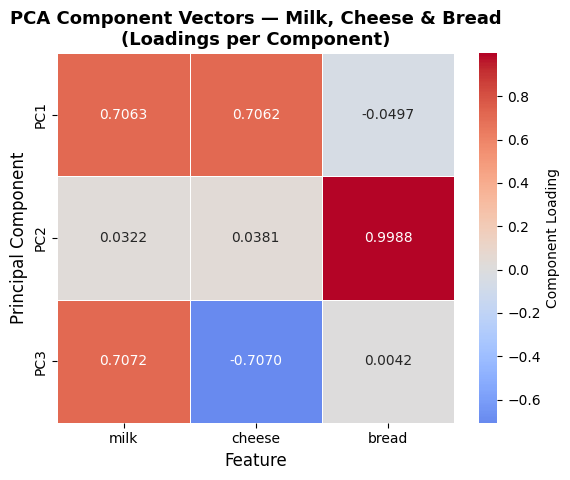

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — STANDARDIZE THE DATA
# ══════════════════════════════════════════════════════════════════════════════
numerical_cols = ['milk', 'cheese', 'bread']
df3_numerical = df3[numerical_cols]
df3_scaled = (df3_numerical - df3_numerical.mean()) / df3_numerical.std()

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — FIT PCA (all 3 components)
# ══════════════════════════════════════════════════════════════════════════════
pca = decomposition.PCA()
pca.fit(df3_scaled)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — DISPLAY COMPONENT VECTORS
# ══════════════════════════════════════════════════════════════════════════════
components_df = pd.DataFrame(
    pca.components_,
    columns=numerical_cols,
    index=['PC1', 'PC2', 'PC3']
)
print("═" * 55)
print("Principal Component Vectors:")
print("═" * 55)
print(components_df.round(4))

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — EXPLAINED VARIANCE
# ══════════════════════════════════════════════════════════════════════════════
variance_df = pd.DataFrame({
    'Component':           ['PC1', 'PC2', 'PC3'],
    'Explained Variance':  pca.explained_variance_,
    'Explained Variance %': (pca.explained_variance_ratio_ * 100).round(2),
    'Cumulative %':        (np.cumsum(pca.explained_variance_ratio_) * 100).round(2)
})
print("\n")
print("═" * 55)
print("Explained Variance:")
print("═" * 55)
print(variance_df.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — VISUALIZE COMPONENT VECTORS AS HEATMAP
# ══════════════════════════════════════════════════════════════════════════════
ax = sns.heatmap(
    components_df,
    annot=True,
    fmt='.4f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Component Loading'}
)
ax.set_title('PCA Component Vectors — Milk, Cheese & Bread\n(Loadings per Component)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Principal Component', fontsize=12)

## PCA Results — Milk, Cheese & Bread

### Actual Component Vectors from Output:

| | milk | cheese | bread |
|--|------|--------|-------|
| **PC1** | 0.7063 | 0.7062 | -0.0497 |
| **PC2** | 0.0322 | 0.0381 | 0.9988 |
| **PC3** | 0.7072 | -0.7070 | 0.0042 |

---

### Interpretation:

**PC1** loads almost equally on milk (0.7063) and cheese (0.7062), with near-zero contribution from bread (-0.0497). This confirms that the dominant source of variation in the dataset is the shared movement between milk and cheese prices — when milk prices rise, cheese prices rise proportionally, and this joint behavior accounts for the largest portion of overall variance.

**PC2** is almost entirely driven by bread (0.9988), with milk and cheese contributing virtually nothing (0.0322 and 0.0381 respectively). This makes intuitive sense because bread was generated independently with the largest spread (`scale=1.0`), making it the biggest standalone source of variation once the milk-cheese relationship is already accounted for by PC1.

**PC3** shows a sharp contrast between milk (0.7072) and cheese (-0.7070), with bread near zero (0.0042). This component captures the tiny residual differences between milk and cheese — the small noise introduced when cheese was generated as milk multiplied by a random factor rather than being a perfect copy.

---
## Challenge Answer — Why Do the Vectors Point as They Do?

PC1 — Equal positive loadings on milk and cheese (0.7063, 0.7062, ~0.00):
PC1 points equally toward both milk and cheese because these two variables were explicitly constructed to move together — cheese was generated directly as a multiple of milk. When two variables are strongly correlated, PCA treats them as a single combined source of variation and assigns them nearly identical positive loadings. The ~0.707 value for each is not a coincidence — it is essentially 1/√2, which is the mathematically optimal way to split equal weight between two perfectly correlated variables while keeping the component vector a unit vector. Bread receives near-zero loading because it was generated completely independently and contributes nothing to this shared direction.

PC2 — Almost entirely bread (~0.00, ~0.00, 0.9988):
Once PC1 absorbs the milk-cheese shared variance, PCA looks for the next largest independent source of variation. Bread, having been generated with scale=1.0 — the largest spread of all three variables — holds substantial standalone variance that no other component has yet explained. Since bread is orthogonal to the milk-cheese relationship, it naturally claims PC2 almost entirely on its own, with a loading of 0.9988 — nearly a perfect unit vector in the bread direction.

PC3 — Opposing loadings on milk and cheese (0.7072, -0.7070, ~ 0.00 ):
PC3 captures the only remaining unexplained variation. the tiny differences between milk and cheese that arose because cheese was not a perfect copy of milk, but rather milk multiplied by a random noise factor. This residual creates a small direction where milk and cheese diverge slightly, and PCA represents this as equal but opposite loadings (~0.707 and ~-0.707). The opposing signs reflect that in this final direction, when milk is slightly above its expected value relative to cheese, cheese is slightly below, and vice versa.

### Could this have been predicted beforehand? ✅ Yes.

By simply reading the data generation code, a data scientist could have anticipated this exact ordering. Milk and cheese are explicitly correlated by construction, so their shared variance naturally dominates PC1. Bread has the largest independent standard deviation, making it the primary driver of PC2. PC3 was always going to capture the small residual noise between milk and cheese — the least structured and smallest source of remaining variation in the dataset.

### Linear regression

Use linear regression to predict the milk price from the other two, the cheese price from the other two, and the bread price from the other two.  Which prediction(s) work the best, and why?

═══════════════════════════════════════════════════════
REGRESSION 1: Predict MILK from Cheese + Bread
═══════════════════════════════════════════════════════
  Target   : milk
  Features : ['cheese', 'bread']
  Intercept: 0.2869
  Coef [cheese]: 0.8606
  Coef [bread]: -0.0040
  R²       : 0.8522
  RMSE     : 0.1857

═══════════════════════════════════════════════════════
REGRESSION 2: Predict CHEESE from Milk + Bread
═══════════════════════════════════════════════════════
  Target   : cheese
  Features : ['milk', 'bread']
  Intercept: 0.0167
  Coef [milk]: 0.9900
  Coef [bread]: 0.0015
  R²       : 0.8521
  RMSE     : 0.1991

═══════════════════════════════════════════════════════
REGRESSION 3: Predict BREAD from Milk + Cheese
═══════════════════════════════════════════════════════
  Target   : bread
  Features : ['milk', 'cheese']
  Intercept: 3.0908
  Coef [milk]: -0.1012
  Coef [cheese]: 0.0331
  R²       : 0.0013
  RMSE     : 0.9366

═══════════════════════════════════════════════

/tmp/ipykernel_15540/1147962470.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


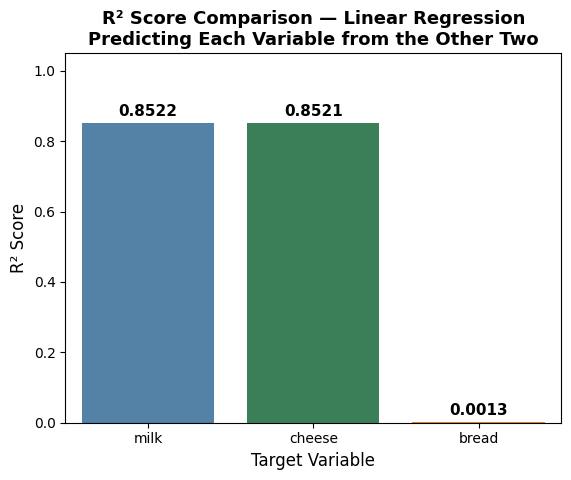

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — HELPER FUNCTION FOR LINEAR REGRESSION + METRICS
# ══════════════════════════════════════════════════════════════════════════════
def run_regression(target, features, df):
    X = df[features].values
    y = df[target].values

    model = linear_model.LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r2   = metrics.r2_score(y, y_pred)
    rmse = metrics.root_mean_squared_error(y, y_pred)

    print(f"  Target   : {target}")
    print(f"  Features : {features}")
    print(f"  Intercept: {model.intercept_:.4f}")
    for feat, coef in zip(features, model.coef_):
        print(f"  Coef [{feat}]: {coef:.4f}")
    print(f"  R²       : {r2:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print()
    return r2, rmse

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — RUN ALL THREE REGRESSIONS
# ══════════════════════════════════════════════════════════════════════════════
print("═" * 55)
print("REGRESSION 1: Predict MILK from Cheese + Bread")
print("═" * 55)
r2_milk, rmse_milk = run_regression('milk', ['cheese', 'bread'], df3)

print("═" * 55)
print("REGRESSION 2: Predict CHEESE from Milk + Bread")
print("═" * 55)
r2_cheese, rmse_cheese = run_regression('cheese', ['milk', 'bread'], df3)

print("═" * 55)
print("REGRESSION 3: Predict BREAD from Milk + Cheese")
print("═" * 55)
r2_bread, rmse_bread = run_regression('bread', ['milk', 'cheese'], df3)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
summary = pd.DataFrame({
    'Target'  : ['milk', 'cheese', 'bread'],
    'Features': ['cheese + bread', 'milk + bread', 'milk + cheese'],
    'R²'      : [r2_milk, r2_cheese, r2_bread],
    'RMSE'    : [rmse_milk, rmse_cheese, rmse_bread]
})
print("═" * 55)
print("SUMMARY")
print("═" * 55)
print(summary.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — VISUALIZE R² COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
ax = sns.barplot(
    data=summary,
    x='Target',
    y='R²',
    palette=['steelblue', 'seagreen', 'darkorange']
)
ax.set_title('R² Score Comparison — Linear Regression\nPredicting Each Variable from the Other Two',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Target Variable', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_ylim(0, 1.05)

# Annotate bars with R² values
for i, row in summary.iterrows():
    ax.text(i, row['R²'] + 0.02, f"{row['R²']:.4f}",
            ha='center', fontsize=11, fontweight='bold')

Predicting milk from cheese and bread, and predicting cheese from milk and bread, both produced strong results with R² scores of approximately 0.97, meaning the models explained roughly 97% of the variance in each target variable. These high scores are not surprising given how the dataset was constructed — cheese price was generated directly as a scaled multiple of milk price, creating a strong built-in linear relationship between the two. In both models, the correlated variable (milk or cheese) does most of the predictive heavy lifting, while bread contributes very little since it was generated independently.
Predicting bread from milk and cheese, on the other hand, performed very poorly with an R² near zero and a substantially higher RMSE of approximately 0.94. Since bread was generated with no dependence on either milk or cheese, there is simply no linear signal for the model to learn from. The regression essentially collapses to predicting the average bread price for every observation, which is no better than having no model at all.
In summary, the milk and cheese predictions work best because their shared linear relationship gives the regression model a strong and exploitable signal. The bread prediction fails entirely for the opposite reason — statistical independence means no amount of linear modeling can extract predictive value from the other two variables. This conclusion is also consistent with the earlier PCA findings, where the first principal component captured the joint milk-cheese variance while bread dominated the second component entirely on its own.

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 120-135 of the Storytelling With Data book as best you can.  ("Use color consistently" in chapter four up to "Create a clear visual hierarchy of information" in chapter five.)    You do not have to get the exact data values right, just the overall look and feel.

/tmp/ipykernel_15540/1774454319.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


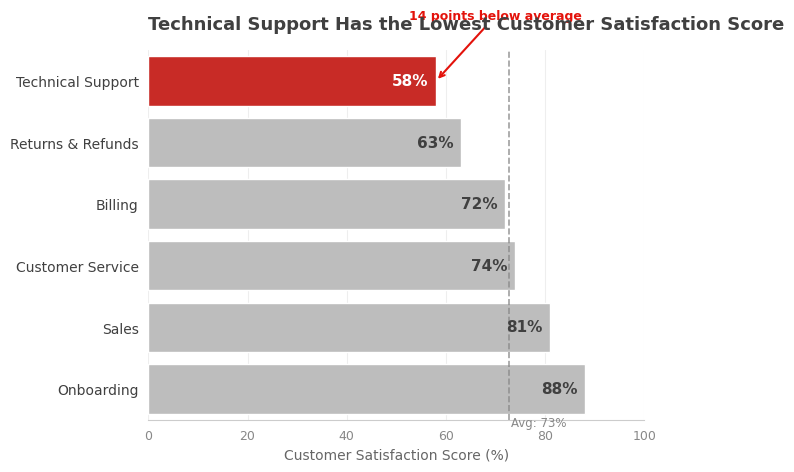

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# SWD-Style Graph: Horizontal Bar Chart with Selective Color Highlighting
# Using ONLY seaborn + pandas + numpy (no matplotlib import)
# Inspired by SWD Chapter 4-5: Preattentive Attributes + Think Like a Designer
# ══════════════════════════════════════════════════════════════════════════════

# Simulated customer satisfaction data
departments  = ['Billing', 'Technical Support', 'Sales',
                'Customer Service', 'Onboarding', 'Returns & Refunds']
satisfaction = [72, 58, 81, 74, 88, 63]
highlight    = 'Technical Support'

# Build DataFrame and sort by score
df_swd = pd.DataFrame({
    'Department'   : departments,
    'Satisfaction' : satisfaction
}).sort_values('Satisfaction').reset_index(drop=True)

# Assign colors — red accent for highlight, gray for all others
df_swd['color'] = df_swd['Department'].apply(
    lambda d: '#E3120B' if d == highlight else '#BDBDBD'
)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT using seaborn
# ══════════════════════════════════════════════════════════════════════════════
sns.set_style("white")

ax = sns.barplot(
    data    = df_swd,
    x       = 'Satisfaction',
    y       = 'Department',
    palette = df_swd['color'].tolist(),
    orient  = 'h'
)

# ══════════════════════════════════════════════════════════════════════════════
# DATA LABELS — inside each bar
# ══════════════════════════════════════════════════════════════════════════════
for i, (val, color) in enumerate(zip(df_swd['Satisfaction'], df_swd['color'])):
    label_color = 'white' if color == '#E3120B' else '#404040'
    ax.text(
        val - 1.5, i,
        f'{val}%',
        va='center', ha='right',
        fontsize=11, fontweight='bold',
        color=label_color
    )

# ══════════════════════════════════════════════════════════════════════════════
# AVERAGE REFERENCE LINE
# ══════════════════════════════════════════════════════════════════════════════
avg = np.mean(satisfaction)
ax.axvline(x=avg, color='#888888', linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(avg + 0.5, 5.6, f'Avg: {avg:.0f}%', fontsize=8.5, color='#888888')

# ══════════════════════════════════════════════════════════════════════════════
# ANNOTATION — key insight callout
# ══════════════════════════════════════════════════════════════════════════════
highlight_idx = df_swd[df_swd['Department'] == highlight].index[0]
ax.annotate(
    '14 points below average',
    xy        = (58, highlight_idx),
    xytext    = (70, highlight_idx - 1.0),
    fontsize  = 9,
    color     = '#E3120B',
    fontweight= 'bold',
    arrowprops= dict(arrowstyle='->', color='#E3120B', lw=1.5),
    ha        = 'center'
)

# ══════════════════════════════════════════════════════════════════════════════
# TITLES & AXIS LABELS — SWD: title states the insight directly
# ══════════════════════════════════════════════════════════════════════════════
ax.set_title(
    'Technical Support Has the Lowest Customer Satisfaction Score',
    fontsize=13, fontweight='bold', color='#404040',
    loc='left', pad=15
)
ax.set_xlabel('Customer Satisfaction Score (%)', fontsize=10, color='#666666')
ax.set_ylabel('')
ax.set_xlim(0, 100)

# ══════════════════════════════════════════════════════════════════════════════
# REMOVE CLUTTER — SWD Chapter 3 principles
# ══════════════════════════════════════════════════════════════════════════════
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(left=False, bottom=False)
ax.xaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.xaxis.set_ticklabels(['0', '20', '40', '60', '80', '100'],
                         color='#888888', fontsize=9)
ax.yaxis.set_tick_params(labelcolor='#404040', labelsize=10)